# Practical Statistics for Data Scientists (Python + R)
# Chapter 1. Exploratory Data Analysis
> (c) 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck

## Loading the rpy2 extension in a notebook with the Python kernel

In [1]:
import sys
import io

stderr_original = sys.stderr
sys.stderr = io.StringIO()

# Loading the extension without noise
%load_ext rpy2.ipython

sys.stderr = stderr_original  # Restore silently

In [2]:
%%R
suppressWarnings(
  invisible(
    try(Sys.setlocale("LC_ALL", "English"), silent = TRUE)
  )
)

## Import packages

### Import Python packages

In [3]:
%matplotlib inline

from pathlib import Path

import pandas as pd
import numpy as np
from scipy.stats import trim_mean
from statsmodels import robust
import wquantiles

import seaborn as sns
import matplotlib.pylab as plt

In [4]:
try:
    import common
    DATA = common.dataDirectory()
except ImportError:
    DATA = Path().resolve() / 'data'

### Import required R packages

In [5]:
%%R
library(dplyr)
library(tidyr)
library(ggplot2)
library(corrplot)
library(gmodels)
library(matrixStats)


Dolaczanie pakietu: 'dplyr'

Nastepujace obiekty zostaly zakryte z 'package:stats':

    filter, lag

Nastepujace obiekty zostaly zakryte z 'package:base':

    intersect, setdiff, setequal, union

corrplot 0.95 loaded

Dolaczanie pakietu: 'matrixStats'

Nastepujacy obiekt zostal zakryty z 'package:dplyr':

    count



## Defining data paths

### Data Assignment - Python

In [6]:
AIRLINE_STATS_CSV = DATA / 'airline_stats.csv'
KC_TAX_CSV = DATA / 'kc_tax.csv.gz'
LC_LOANS_CSV = DATA / 'lc_loans.csv'
AIRPORT_DELAYS_CSV = DATA / 'dfw_airline.csv'
SP500_DATA_CSV = DATA / 'sp500_data.csv.gz'
SP500_SECTORS_CSV = DATA / 'sp500_sectors.csv'
STATE_CSV = DATA / 'state.csv'

### Data Assignment - R

In [7]:
%%R 
PSDS_PATH <- file.path(dirname(dirname(getwd())))
 
state <- read.csv(file.path(PSDS_PATH, 'data', 'state.csv'))
dfw <- read.csv(file.path(PSDS_PATH, 'data', 'dfw_airline.csv'))
sp500_px <- read.csv(file.path(PSDS_PATH, 'data', 'sp500_data.csv.gz'), row.names=1)
sp500_sym <- read.csv(file.path(PSDS_PATH, 'data', 'sp500_sectors.csv'), stringsAsFactors = FALSE)
kc_tax <- read.csv(file.path(PSDS_PATH, 'data', 'kc_tax.csv.gz'))
lc_loans <- read.csv(file.path(PSDS_PATH, 'data', 'lc_loans.csv'))
airline_stats <- read.csv(file.path(PSDS_PATH, 'data', 'airline_stats.csv'), stringsAsFactors = FALSE)
airline_stats$airline <- ordered(airline_stats$airline, 
                                 levels=c('Alaska', 'American', 'Jet Blue', 'Delta', 'United', 'Southwest'))

# Estimates of Location
## Example: Location Estimates of Population and Murder Rates

### Python

In [8]:
# Table 1-2
state = pd.read_csv(STATE_CSV)
print(state.head(8))

         State  Population  Murder.Rate Abbreviation
0      Alabama     4779736          5.7           AL
1       Alaska      710231          5.6           AK
2      Arizona     6392017          4.7           AZ
3     Arkansas     2915918          5.6           AR
4   California    37253956          4.4           CA
5     Colorado     5029196          2.8           CO
6  Connecticut     3574097          2.4           CT
7     Delaware      897934          5.8           DE


Compute the mean, trimmed mean, and median for Population. For `mean` and `median` we can use the _pandas_ methods of the data frame. The trimmed mean requires the `trim_mean` function in _scipy.stats_.

In [9]:
state = pd.read_csv(STATE_CSV)
print(state['Population'].mean())

6162876.3


In [10]:
print(trim_mean(state['Population'], 0.1))

4783697.125


In [11]:
print(state['Population'].median())

4436369.5


Weighted mean is available with numpy. For weighted median, we can use the specialised package `wquantiles` (https://pypi.org/project/wquantiles/).

In [12]:
print(state['Murder.Rate'].mean())

4.066


In [13]:
print(np.average(state['Murder.Rate'], weights=state['Population']))

4.445833981123393


In [14]:
print(wquantiles.median(state['Murder.Rate'], weights=state['Population']))

4.4


### R

In [15]:
%%R
# Table 1-2
state_asc <- state
state_asc[['Population']] <- formatC(state_asc[['Population']], format='d', digits=0, big.mark=',')
state_asc[1:8,]

        State Population Murder.Rate Abbreviation
     Alabama  4,779,736         5.7           AL
      Alaska    710,231         5.6           AK
     Arizona  6,392,017         4.7           AZ
    Arkansas  2,915,918         5.6           AR
  California 37,253,956         4.4           CA
    Colorado  5,029,196         2.8           CO
 Connecticut  3,574,097         2.4           CT
    Delaware    897,934         5.8           DE


In [16]:
%%R
results <- c(
    mean(state[['Population']]),
    mean(state[['Population']], trim=0.1),
    median(state[['Population']])
)
print(results)

[1] 6162876 4783697 4436370


In [17]:
%%R
library('matrixStats')
results <- c(
    weighted.mean(state[['Murder.Rate']], w=state[['Population']]),
    weightedMedian(state[['Murder.Rate']], w=state[['Population']])
)
print(results)

[1] 4.445834 4.400000


# Estimates of Variability

### Python

In [18]:
# Table 1-2
print(state.head(8))

         State  Population  Murder.Rate Abbreviation
0      Alabama     4779736          5.7           AL
1       Alaska      710231          5.6           AK
2      Arizona     6392017          4.7           AZ
3     Arkansas     2915918          5.6           AR
4   California    37253956          4.4           CA
5     Colorado     5029196          2.8           CO
6  Connecticut     3574097          2.4           CT
7     Delaware      897934          5.8           DE


Standard deviation

In [19]:
print(state['Population'].std())

6848235.347401142


Interquartile range is calculated as the difference of the 75% and 25% quantile.

In [20]:
print(state['Population'].quantile(0.75) - state['Population'].quantile(0.25))

4847308.0


Median absolute deviation from the median can be calculated with a method in _statsmodels_

In [21]:
print(robust.scale.mad(state['Population']))
print(abs(state['Population'] - state['Population'].median()).median() / 0.6744897501960817)

3849876.1459979336
3849876.1459979336


### R

In [22]:
%%R
results <- c(
    sd(state[['Population']]),
    IQR(state[['Population']]),
    mad(state[['Population']])
)
print(results)

[1] 6848235 4847308 3849870


## Percentiles and Boxplots

### Python
_Pandas_ has the `quantile` method for data frames.

In [23]:
print(state['Murder.Rate'].quantile([0.05, 0.25, 0.5, 0.75, 0.95]))

0.05    1.600
0.25    2.425
0.50    4.000
0.75    5.550
0.95    6.510
Name: Murder.Rate, dtype: float64


In [24]:
# Table 1.4
percentages = [0.05, 0.25, 0.5, 0.75, 0.95]
df = pd.DataFrame(state['Murder.Rate'].quantile(percentages))
df.index = [f'{p * 100}%' for p in percentages]
print(df.transpose())

             5.0%  25.0%  50.0%  75.0%  95.0%
Murder.Rate   1.6  2.425    4.0   5.55   6.51


_Pandas_ provides a number of basic exploratory plots; one of them are boxplots

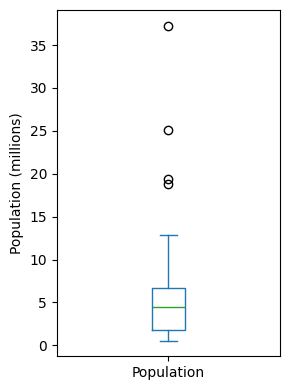

In [25]:
ax = (state['Population']/1_000_000).plot.box(figsize=(3, 4))
ax.set_ylabel('Population (millions)')

plt.tight_layout()
plt.show()

### R

In [26]:
%%R
quantile(state[['Murder.Rate']], p=c(.05, .25, .5, .75, .95))

   5%   25%   50%   75%   95% 
1.600 2.425 4.000 5.550 6.510 


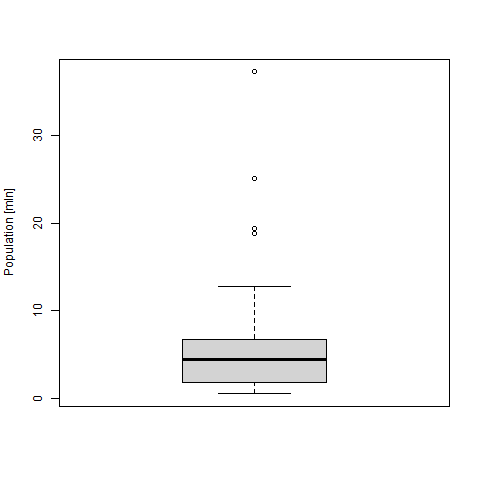

In [27]:
%%R
boxplot(state[['Population']]/1000000, ylab='Population [mln]')

## Frequency Table and Histograms

### Python
The `cut` method for _pandas_ data splits the dataset into bins. There are a number of arguments for the method. The following code creates equal sized bins. The method `value_counts` returns a frequency table.

In [28]:
binnedPopulation = pd.cut(state['Population'], 10)
print(binnedPopulation.value_counts())

Population
(526935.67, 4232659.0]      24
(4232659.0, 7901692.0]      14
(7901692.0, 11570725.0]      6
(11570725.0, 15239758.0]     2
(15239758.0, 18908791.0]     1
(18908791.0, 22577824.0]     1
(22577824.0, 26246857.0]     1
(33584923.0, 37253956.0]     1
(26246857.0, 29915890.0]     0
(29915890.0, 33584923.0]     0
Name: count, dtype: int64


In [29]:
# Table 1.5
binnedPopulation.name = 'binnedPopulation'
df = pd.concat([state, binnedPopulation], axis=1)
df = df.sort_values(by='Population')

groups = []
for group, subset in df.groupby(by='binnedPopulation', observed=False):
    groups.append({
        'BinRange': group,
        'Count': len(subset),
        'States': ','.join(subset.Abbreviation)
    })
print(pd.DataFrame(groups))

                   BinRange  Count  \
0    (526935.67, 4232659.0]     24   
1    (4232659.0, 7901692.0]     14   
2   (7901692.0, 11570725.0]      6   
3  (11570725.0, 15239758.0]      2   
4  (15239758.0, 18908791.0]      1   
5  (18908791.0, 22577824.0]      1   
6  (22577824.0, 26246857.0]      1   
7  (26246857.0, 29915890.0]      0   
8  (29915890.0, 33584923.0]      0   
9  (33584923.0, 37253956.0]      1   

                                              States  
0  WY,VT,ND,AK,SD,DE,MT,RI,NH,ME,HI,ID,NE,WV,NM,N...  
1          KY,LA,SC,AL,CO,MN,WI,MD,MO,TN,AZ,IN,MA,WA  
2                                  VA,NJ,NC,GA,MI,OH  
3                                              PA,IL  
4                                                 FL  
5                                                 NY  
6                                                 TX  
7                                                     
8                                                     
9                              

_Pandas_ also supports histograms for exploratory data analysis.

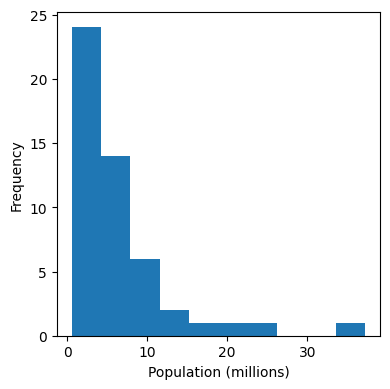

In [30]:
ax = (state['Population'] / 1_000_000).plot.hist(figsize=(4, 4))
ax.set_xlabel('Population (millions)')

plt.tight_layout()
plt.show()

### R

In [31]:
%%R
breaks <- seq(from=min(state[['Population']]), 
              to=max(state[['Population']]), length=11)
pop_freq <- cut(state[['Population']], breaks=breaks, 
                right=TRUE, include.lowest=TRUE)
state['PopFreq'] <- pop_freq
table(pop_freq)

pop_freq
[5.64e+05,4.23e+06]  (4.23e+06,7.9e+06]  (7.9e+06,1.16e+07] (1.16e+07,1.52e+07] 
                 24                  14                   6                   2 
(1.52e+07,1.89e+07] (1.89e+07,2.26e+07] (2.26e+07,2.62e+07] (2.62e+07,2.99e+07] 
                  1                   1                   1                   0 
(2.99e+07,3.36e+07] (3.36e+07,3.73e+07] 
                  0                   1 


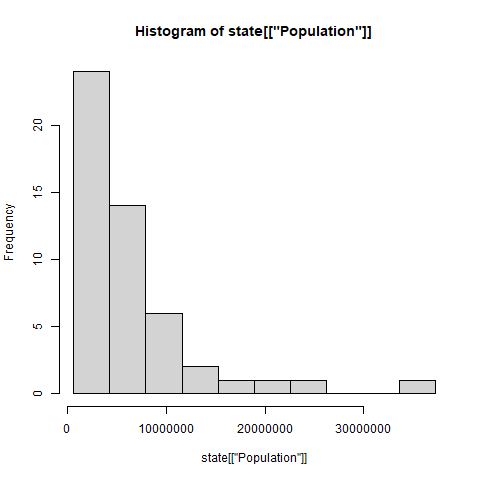

In [32]:
%%R
options(scipen=5)
hist(state[['Population']], breaks=breaks)

## Density Estimates


### Python
Density is an alternative to histograms that can provide more insight into the distribution of the data points. Use the argument `bw_method` to control the smoothness of the density curve.

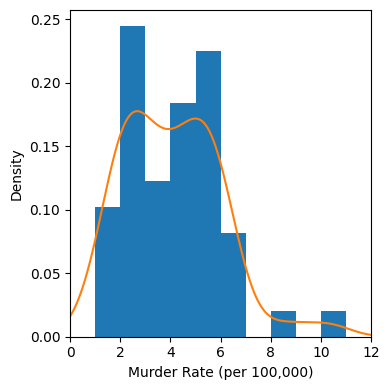

In [33]:
ax = state['Murder.Rate'].plot.hist(density=True, xlim=[0, 12], 
                                    bins=range(1,12), figsize=(4, 4))
state['Murder.Rate'].plot.density(ax=ax)
ax.set_xlabel('Murder Rate (per 100,000)')

plt.tight_layout()
plt.show()

### R
Density is an alternative to histograms that can provide more insight into the distribution of the data points. 

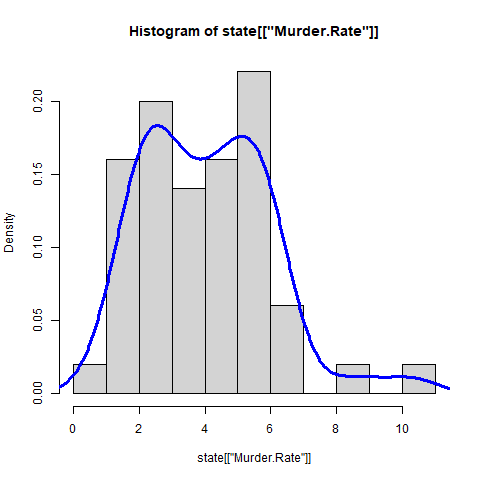

In [34]:
%%R
hist(state[['Murder.Rate']], freq=FALSE )
lines(density(state[['Murder.Rate']]), lwd=3, col='blue')

# Exploring Binary and Categorical Data

### Python

In [35]:
# Table 1-6
dfw = pd.read_csv(AIRPORT_DELAYS_CSV)
print(100 * dfw / dfw.values.sum())

     Carrier        ATC   Weather  Security    Inbound
0  23.022989  30.400781  4.025214  0.122937  42.428079


_Pandas_ also supports bar charts for displaying a single categorical variable.

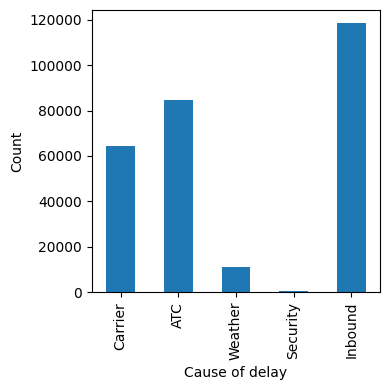

In [36]:
ax = dfw.transpose().plot.bar(figsize=(4, 4), legend=False)
ax.set_xlabel('Cause of delay')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

### R

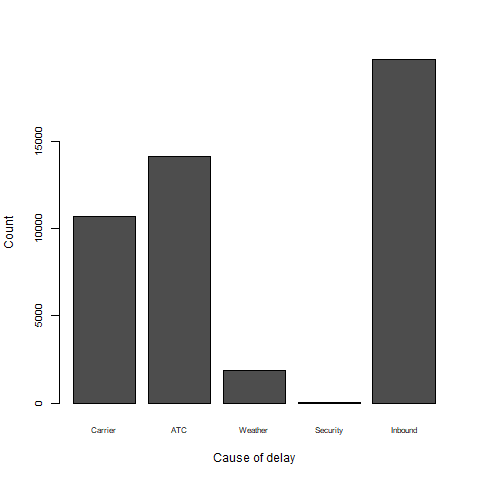

In [37]:
%%R
barplot(as.matrix(dfw) / 6, cex.axis=0.8, cex.names=0.7, 
        xlab='Cause of delay', ylab='Count')

# Correlation


### Python
First read the required datasets

In [38]:
sp500_sym = pd.read_csv(SP500_SECTORS_CSV)
sp500_px = pd.read_csv(SP500_DATA_CSV, index_col=0)

In [39]:
# Table 1-7
# Determine telecommunications symbols
telecomSymbols = sp500_sym[sp500_sym['sector'] == 'telecommunications_services']['symbol']

# Filter data for dates July 2012 through June 2015
telecom = sp500_px.loc[sp500_px.index >= '2012-07-01', telecomSymbols]
telecom.corr()
print(telecom)

                   T       CTL       FTR        VZ      LVLT
2012-07-02  0.422496  0.140847  0.070879  0.554180 -0.519998
2012-07-03 -0.177448  0.066280  0.070879 -0.025976 -0.049999
2012-07-05 -0.160548 -0.132563  0.055128 -0.051956 -0.180000
2012-07-06  0.342205  0.132563  0.007875  0.140106 -0.359999
2012-07-09  0.136883  0.124279 -0.023626  0.253943  0.180000
...              ...       ...       ...       ...       ...
2015-06-25  0.049342 -1.600000 -0.040000 -0.187790 -0.330002
2015-06-26 -0.256586  0.039999 -0.070000  0.029650 -0.739998
2015-06-29 -0.098685 -0.559999 -0.060000 -0.504063 -1.360000
2015-06-30 -0.503298 -0.420000 -0.070000 -0.523829  0.199997
2015-07-01 -0.019737  0.080000 -0.050000  0.355811  0.139999

[754 rows x 5 columns]


Next we focus on funds traded on major exchanges (sector == 'etf'). 

In [40]:
etfs = sp500_px.loc[sp500_px.index > '2012-07-01', 
                    sp500_sym[sp500_sym['sector'] == 'etf']['symbol']]
print(etfs.head())

                 XLI       QQQ       SPY       DIA       GLD    VXX       USO  \
2012-07-02 -0.376098  0.096313  0.028223 -0.242796  0.419998 -10.40  0.000000   
2012-07-03  0.376099  0.481576  0.874936  0.728405  0.490006  -3.52  0.250000   
2012-07-05  0.150440  0.096313 -0.103487  0.149420  0.239991   6.56 -0.070000   
2012-07-06 -0.141040 -0.491201  0.018819 -0.205449 -0.519989  -8.80 -0.180000   
2012-07-09  0.244465 -0.048160 -0.056445 -0.168094  0.429992  -0.48  0.459999   

                 IWM       XLE       XLY       XLU       XLB       XTL  \
2012-07-02  0.534641  0.028186  0.095759  0.098311 -0.093713  0.019076   
2012-07-03  0.926067  0.995942  0.000000 -0.044686  0.337373  0.000000   
2012-07-05 -0.171848 -0.460387  0.306431 -0.151938  0.103086  0.019072   
2012-07-06 -0.229128  0.206706  0.153214  0.080437  0.018744 -0.429213   
2012-07-09 -0.190939 -0.234892 -0.201098 -0.035751 -0.168687  0.000000   

                 XLV       XLP       XLF       XLK  
2012-07-02 -0.0

Due to the large number of columns in this table, looking at the correlation matrix is cumbersome and it's more convenient to plot the correlation as a heatmap. The _seaborn_ package provides a convenient implementation for heatmaps.

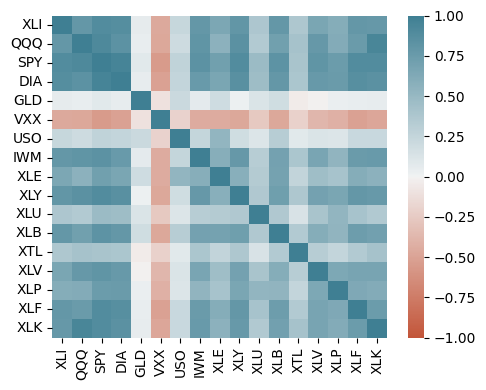

In [41]:
fig, ax = plt.subplots(figsize=(5, 4))
ax = sns.heatmap(etfs.corr(), vmin=-1, vmax=1, 
                 cmap=sns.diverging_palette(20, 220, as_cmap=True),
                 ax=ax)

plt.tight_layout()
plt.show()

The above heatmap works when you have color. For the greyscale images, as used in the book, we need to visualize the direction as well. The following code shows the strength of the correlation using ellipses.

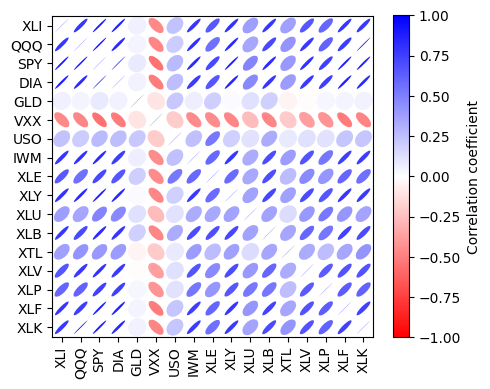

In [42]:
from matplotlib.collections import EllipseCollection
from matplotlib.colors import Normalize

def plot_corr_ellipses(data, figsize=None, **kwargs):
    ''' https://stackoverflow.com/a/34558488 '''
    M = np.array(data)
    if not M.ndim == 2:
        raise ValueError('data must be a 2D array')
    fig, ax = plt.subplots(1, 1, figsize=figsize, subplot_kw={'aspect':'equal'})
    ax.set_xlim(-0.5, M.shape[1] - 0.5)
    ax.set_ylim(-0.5, M.shape[0] - 0.5)
    ax.invert_yaxis()

    # xy locations of each ellipse center
    xy = np.indices(M.shape)[::-1].reshape(2, -1).T

    # set the relative sizes of the major/minor axes according to the strength of
    # the positive/negative correlation
    w = np.ones_like(M).ravel() + 0.01
    h = 1 - np.abs(M).ravel() - 0.01
    a = 45 * np.sign(M).ravel()

    ec = EllipseCollection(widths=w, heights=h, angles=a, units='x', offsets=xy,
                           norm=Normalize(vmin=-1, vmax=1),
                           transOffset=ax.transData, array=M.ravel(), **kwargs)
    ax.add_collection(ec)

    # if data is a DataFrame, use the row/column names as tick labels
    if isinstance(data, pd.DataFrame):
        ax.set_xticks(np.arange(M.shape[1]))
        ax.set_xticklabels(data.columns, rotation=90)
        ax.set_yticks(np.arange(M.shape[0]))
        ax.set_yticklabels(data.index)

    return ec, ax

m, ax = plot_corr_ellipses(etfs.corr(), figsize=(5, 4), cmap='bwr_r')
cb = plt.colorbar(m, ax=ax)
cb.set_label('Correlation coefficient')

plt.tight_layout()
plt.show()

### R

In [43]:
%%R
telecom <- sp500_px[, sp500_sym[sp500_sym$sector == 'telecommunications_services', 'symbol']]
telecom <- telecom[row.names(telecom) > '2012-07-01',]
telecom_cor <- cor(telecom)

Next we focus on funds traded on major exchanges (sector == 'etf'). 

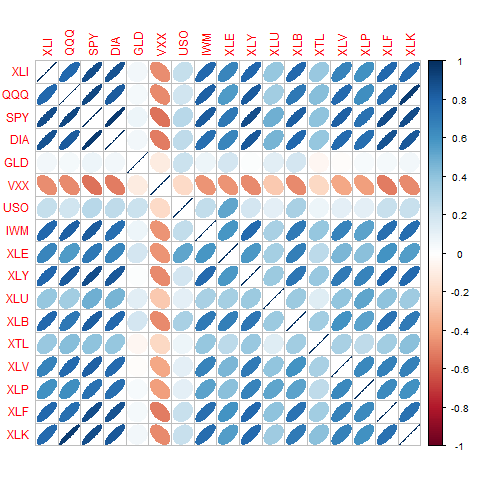

In [44]:
%%R
etfs <- sp500_px[row.names(sp500_px) > '2012-07-01', 
                 sp500_sym[sp500_sym$sector == 'etf', 'symbol']]
corrplot(cor(etfs), method='ellipse')

## Scatterplots


### Python
Simple scatterplots are supported by _pandas_. Specifying the marker as `$\u25EF$` uses an open circle for each point.

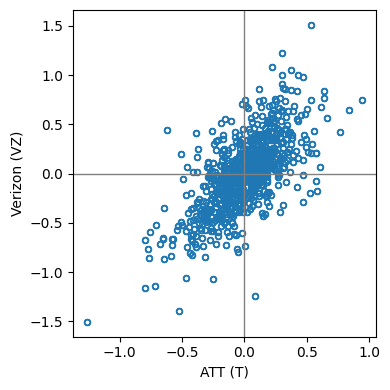

In [45]:
ax = telecom.plot.scatter(x='T', y='VZ', figsize=(4, 4), marker='$\u25EF$')
ax.set_xlabel('ATT (T)')
ax.set_ylabel('Verizon (VZ)')
ax.axhline(0, color='grey', lw=1)
ax.axvline(0, color='grey', lw=1)

plt.tight_layout()
plt.show()

Line2D(_child2)


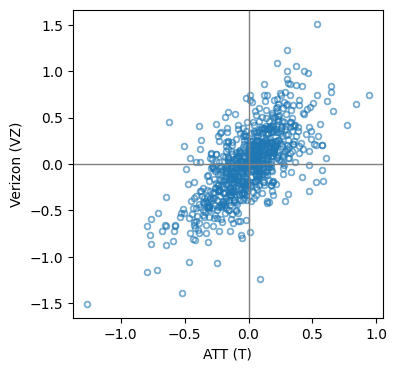

In [46]:
ax = telecom.plot.scatter(x='T', y='VZ', figsize=(4, 4), marker='$\u25EF$', alpha=0.5)
ax.set_xlabel('ATT (T)')
ax.set_ylabel('Verizon (VZ)')
ax.axhline(0, color='grey', lw=1)
print(ax.axvline(0, color='grey', lw=1))

### R

[1] 754   5


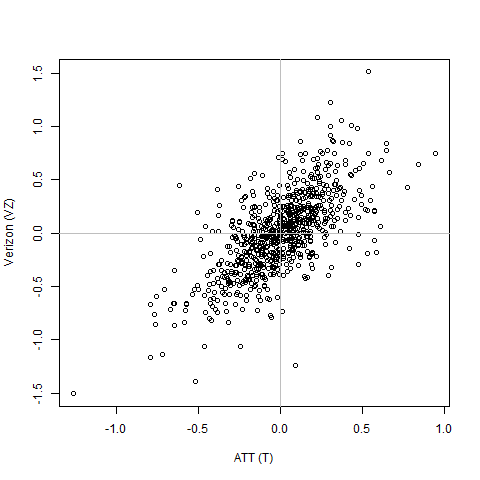

In [47]:
%%R
# plot(telecom$T, telecom$VZ, xlab='T', ylab='VZ', cex=.8)
plot(telecom$T, telecom$VZ, xlab='ATT (T)', ylab='Verizon (VZ)')
abline(h=0, v=0, col='grey')
dim(telecom)

# Exploring Two or More Variables
Load the kc_tax dataset and filter based on a variety of criteria

### Python

In [48]:
kc_tax = pd.read_csv(KC_TAX_CSV)
kc_tax0 = kc_tax.loc[(kc_tax.TaxAssessedValue < 750000) & 
                     (kc_tax.SqFtTotLiving > 100) &
                     (kc_tax.SqFtTotLiving < 3500), :]
print(kc_tax0.shape)

(432693, 3)


### R

In [49]:
%%R
kc_tax0 <- subset(kc_tax, TaxAssessedValue < 750000 & 
                  SqFtTotLiving > 100 &
                  SqFtTotLiving < 3500)
nrow(kc_tax0)

[1] 432693


## Hexagonal binning and Contours 
### Plotting numeric versus numeric data

### Python
If the number of data points gets large, scatter plots will no longer be meaningful. Here methods that visualize densities are more useful. The `hexbin` method for _pandas_ data frames is one powerful approach.

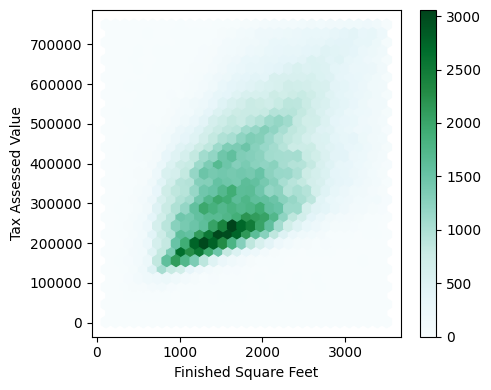

In [50]:
ax = kc_tax0.plot.hexbin(x='SqFtTotLiving', y='TaxAssessedValue',
                         gridsize=30, sharex=False, figsize=(5, 4))
ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax Assessed Value')

plt.tight_layout()
plt.show()

The _seaborn_ kdeplot is a two-dimensional extension of the density plot. The calculation of the 2D-density for the full dataset takes several minutes. It is sufficient to create the visualization with a smaller sample of the dataset. With 10,000 data points, creating the graph takes only seconds. While some details may be lost, the overall shape is preserved. 

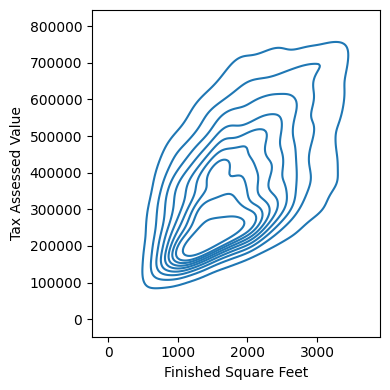

In [51]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.kdeplot(data=kc_tax0.sample(10000), x='SqFtTotLiving', y='TaxAssessedValue', ax=ax)
ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax Assessed Value')

plt.tight_layout()
plt.show()

### R
If the number of data points gets large, scatter plots will no longer be meaningful. Here methods that visualize densities are more useful. The `stat_hexbin` method for is one powerful approach.

pakiet 'hexbin' zostal pomyslnie rozpakowany oraz sumy MD5 zostaly sprawdzone

Pobrane pakiety binarne sa w
	C:\Users\micha\AppData\Local\Temp\RtmpS23bTq\downloaded_packages


trying URL 'https://cloud.r-project.org/bin/windows/contrib/4.4/hexbin_1.28.5.zip'
Content type 'application/zip' length 1605269 bytes (1.5 MB)
downloaded 1.5 MB



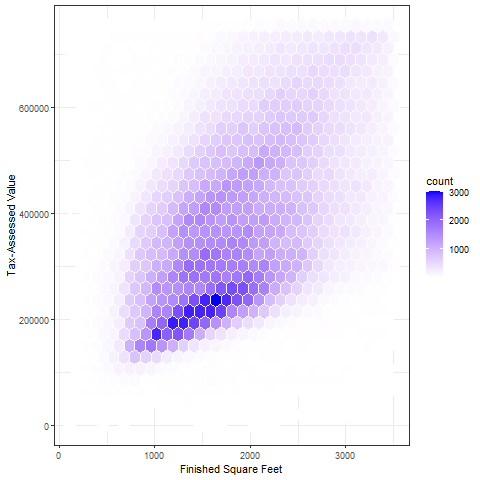

In [52]:
%%R
install.packages("hexbin", repos="https://cloud.r-project.org/")
library(hexbin)

graph <- ggplot(kc_tax0, (aes(x=SqFtTotLiving, y=TaxAssessedValue))) + 
  stat_binhex(color='white') + 
  theme_bw() + 
  scale_fill_gradient(low='white', high='blue') +
  scale_y_continuous(labels = function(x) format(x, scientific = FALSE)) +
  labs(x='Finished Square Feet', y='Tax-Assessed Value')
graph

Visualize as a two-dimensional extension of the density plot. 

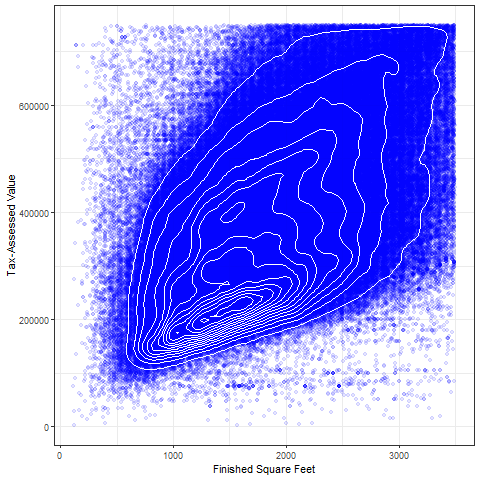

In [53]:
%%R
graph <- ggplot(kc_tax0, aes(SqFtTotLiving, TaxAssessedValue)) +
  theme_bw() + 
  geom_point(color='blue', alpha=0.1) + 
  geom_density2d(color='white') + 
  scale_y_continuous(labels = function(x) format(x, scientific = FALSE)) +
  labs(x='Finished Square Feet', y='Tax-Assessed Value')
graph

## Two Categorical Variables
Load the `lc_loans` dataset

In [54]:
lc_loans = pd.read_csv(LC_LOANS_CSV)

### Python

In [55]:
# Table 1-8(1)
crosstab = lc_loans.pivot_table(index='grade', columns='status', 
                                aggfunc=lambda x: len(x), margins=True)
print(crosstab)

status  Charged Off  Current  Fully Paid  Late     All
grade                                                 
A              1562    50051       20408   469   72490
B              5302    93852       31160  2056  132370
C              6023    88928       23147  2777  120875
D              5007    53281       13681  2308   74277
E              2842    24639        5949  1374   34804
F              1526     8444        2328   606   12904
G               409     1990         643   199    3241
All           22671   321185       97316  9789  450961


In [56]:
# Table 1-8(2)
df = crosstab.copy().loc['A':'G',:].astype(float)
df.loc[:,'Charged Off':'Late'] = df.loc[:,'Charged Off':'Late'].div(df['All'], axis=0)
df['All'] = df['All'] / sum(df['All'])
perc_crosstab = df
print(perc_crosstab)

status  Charged Off   Current  Fully Paid      Late       All
grade                                                        
A          0.021548  0.690454    0.281528  0.006470  0.160746
B          0.040054  0.709013    0.235401  0.015532  0.293529
C          0.049828  0.735702    0.191495  0.022974  0.268039
D          0.067410  0.717328    0.184189  0.031073  0.164708
E          0.081657  0.707936    0.170929  0.039478  0.077177
F          0.118258  0.654371    0.180409  0.046962  0.028614
G          0.126196  0.614008    0.198396  0.061401  0.007187


### R

In [57]:
%%R
x_tab <- CrossTable(lc_loans$grade, lc_loans$status, 
                    prop.c=FALSE, prop.chisq=FALSE, prop.t=FALSE)


 
   Cell Contents
|-------------------------|
|                       N |
|           N / Row Total |
|-------------------------|

 
Total Observations in Table:  450961 

 
               | lc_loans$status 
lc_loans$grade | Charged Off |     Current |  Fully Paid |        Late |   Row Total | 
---------------|-------------|-------------|-------------|-------------|-------------|
             A |        1562 |       50051 |       20408 |         469 |       72490 | 
               |       0.022 |       0.690 |       0.282 |       0.006 |       0.161 | 
---------------|-------------|-------------|-------------|-------------|-------------|
             B |        5302 |       93852 |       31160 |        2056 |      132370 | 
               |       0.040 |       0.709 |       0.235 |       0.016 |       0.294 | 
---------------|-------------|-------------|-------------|-------------|-------------|
             C |        6023 |       88928 |       23147 |        2777 |      120875 | 
 

## Categorical and Numeric Data


### Python
_Pandas_ boxplots of a column can be grouped by a different column.

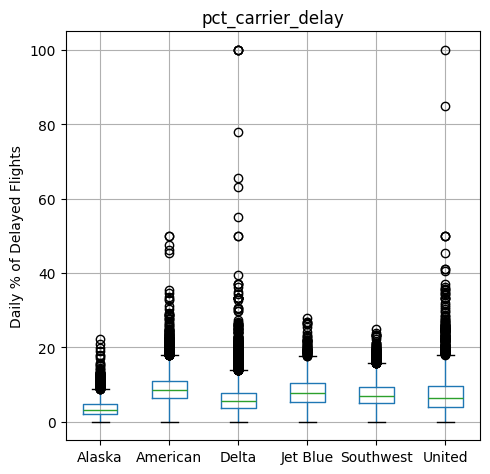

In [58]:
airline_stats = pd.read_csv(AIRLINE_STATS_CSV)
airline_stats.head()
ax = airline_stats.boxplot(by='airline', column='pct_carrier_delay',
                           figsize=(5, 5))
ax.set_xlabel('')
ax.set_ylabel('Daily % of Delayed Flights')
plt.suptitle('')

plt.tight_layout()
plt.show()

_Pandas_ also supports a variation of boxplots called _violinplot_. 

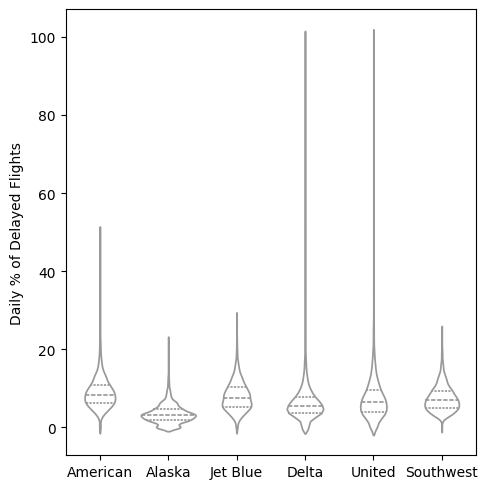

In [59]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.violinplot(data=airline_stats, x='airline', y='pct_carrier_delay',
               ax=ax, inner='quartile', color='white')
ax.set_xlabel('')
ax.set_ylabel('Daily % of Delayed Flights')

plt.tight_layout()
plt.show()

### R

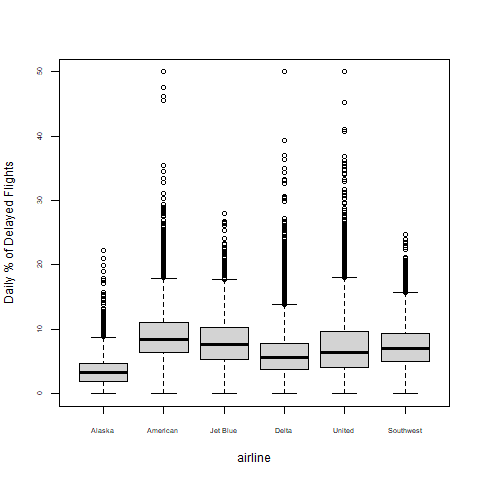

In [60]:
%%R
boxplot(pct_carrier_delay ~ airline, data=airline_stats, ylim=c(0, 50), 
        cex.axis=.6, ylab='Daily % of Delayed Flights')

Variation of boxplots called _violinplot_. 

R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1: Removed 28 rows containing non-finite outside the scale range (`stat_ydensity()`). 
  
R callback write-console: 2: Removed 28 rows containing non-finite outside the scale range (`stat_ydensity()`). 
  


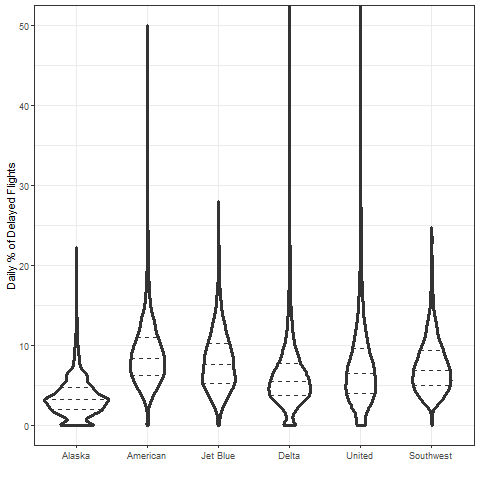

In [61]:
%%R
graph <- ggplot(data=airline_stats, aes(airline, pct_carrier_delay)) + 
  geom_violin(draw_quantiles = c(.25,.5,.75), linetype=2) +
  geom_violin(fill=NA, linewidth=1.1) +
  coord_cartesian(ylim=c(0, 50)) +
  labs(x='', y='Daily % of Delayed Flights') +
  theme_bw()
graph


## Visualizing Multiple Variables

### Python

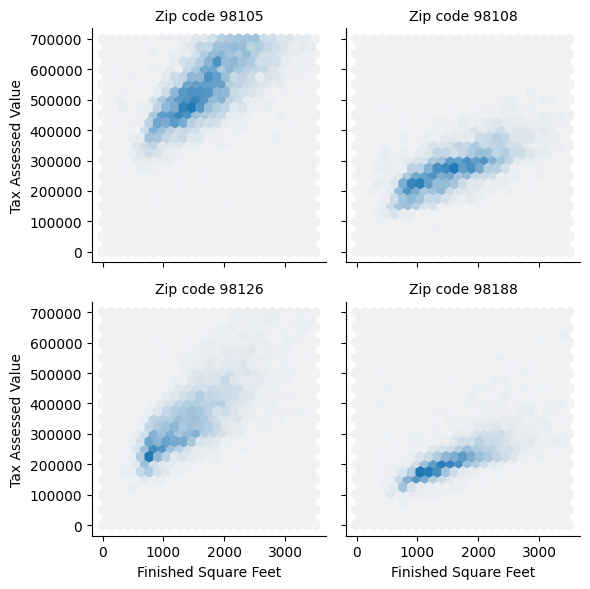

In [62]:
zip_codes = [98188, 98105, 98108, 98126]
kc_tax_zip = kc_tax0.loc[kc_tax0.ZipCode.isin(zip_codes),:]
kc_tax_zip

def hexbin(x, y, color, **kwargs):
    cmap = sns.light_palette(color, as_cmap=True)
    plt.hexbin(x, y, gridsize=25, cmap=cmap, **kwargs)

g = sns.FacetGrid(kc_tax_zip, col='ZipCode', col_wrap=2)
g.map(hexbin, 'SqFtTotLiving', 'TaxAssessedValue', 
      extent=[0, 3500, 0, 700000])
g.set_axis_labels('Finished Square Feet', 'Tax Assessed Value')
g.set_titles('Zip code {col_name:.0f}')

plt.tight_layout()
plt.show()

### R

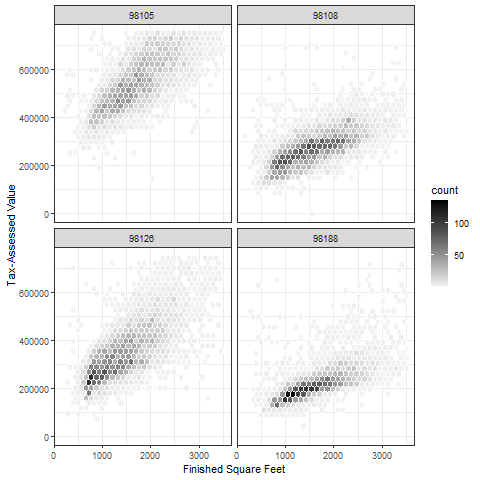

In [63]:
%%R
graph <- ggplot(subset(kc_tax0, ZipCode %in% c(98188, 98105, 98108, 98126)),
                aes(x=SqFtTotLiving, y=TaxAssessedValue)) + 
  stat_binhex(colour='white') + 
  theme_bw() + 
  scale_fill_gradient(low='gray95', high='black') +
  scale_y_continuous(labels = function(x) format(x, scientific = FALSE)) +
  labs(x='Finished Square Feet', y='Tax-Assessed Value') +
  facet_wrap('ZipCode')
graph